# 🌿 Tobacco Leaf Disease Detection — Data Analysis & Model Evaluation

**Project:** Folium — Tobacco Leaf Disease Detection & Quality Grading  
**Dataset:** 6,904 total images across 3 disease classes  
**Model:** MobileNetV2 Transfer Learning  

---
This notebook covers:
1. Dataset overview & statistics
2. Class distribution (overall and per split)
3. Train / Validation / Test split analysis
4. Sample image gallery per class
5. Image resolution & pixel statistics
6. Pixel intensity distributions per class
7. Model performance — accuracy, precision, recall, F1
8. Confusion matrix
9. Training curves (accuracy & loss)
10. Summary statistics table

In [1]:
import os, sys, json, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from PIL import Image

warnings.filterwarnings("ignore")

# ── Paths ────────────────────────────────────────────────────────────────────
NB_DIR      = Path(os.path.abspath(""))
ROOT        = NB_DIR.parent
DATA_DIR    = ROOT / "data" / "raw"
DISEASE_DIR = DATA_DIR / "disease"
OUTPUTS_DIR = ROOT / "outputs"

# ── Style ────────────────────────────────────────────────────────────────────
PALETTE  = ["#4CAF50", "#FF9800", "#2196F3"]          # green / orange / blue
PALETTE2 = ["#388E3C", "#F57C00", "#1565C0"]          # darker shades
sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False,
                     "axes.spines.right": False})

CLASS_NAMES = ["Alternaria_Leaf_Spot", "Cercospora_Leaf_Spot", "Healthy"]
LABELS      = ["Alternaria\nLeaf Spot", "Cercospora\nLeaf Spot", "Healthy"]

print("✅ Imports OK")
print(f"   Disease dir : {DISEASE_DIR}")
print(f"   Outputs dir : {OUTPUTS_DIR}")

✅ Imports OK
   Disease dir : c:\Users\warob\OneDrive\Desktop\CAREER PROJECTS\tobacco-leaf-system\ml\data\raw\disease
   Outputs dir : c:\Users\warob\OneDrive\Desktop\CAREER PROJECTS\tobacco-leaf-system\ml\outputs


## 1. Dataset Overview & Statistics

In [2]:
# ── Overall class counts (disease/ folder) ───────────────────────────────────
overall = {cls: len(list((DISEASE_DIR / cls).glob("*.*"))) for cls in CLASS_NAMES}
total   = sum(overall.values())

print("=" * 52)
print(f"{'CLASS':<30} {'COUNT':>7}  {'%':>6}")
print("-" * 52)
for cls, cnt in overall.items():
    print(f"{cls:<30} {cnt:>7,}  {cnt/total*100:>5.1f}%")
print("-" * 52)
print(f"{'TOTAL':<30} {total:>7,}  100.0%")
print("=" * 52)

# ── Train / Valid / Test splits (raw folder names) ───────────────────────────
SPLIT_MAP = {
    "alternaria alternata":                                "Alternaria_Leaf_Spot",
    "cercospora nicotianae":                               "Cercospora_Leaf_Spot",
    "no cercospora nicotianae or alternaria alternata present": "Healthy",
}
splits = {}
for split in ["train", "valid", "test"]:
    split_dir = DATA_DIR / split
    if not split_dir.exists():
        continue
    counts = {}
    for raw_name, mapped in SPLIT_MAP.items():
        p = split_dir / raw_name
        counts[mapped] = len(list(p.glob("*.*"))) if p.exists() else 0
    splits[split] = counts

split_df = pd.DataFrame(splits).T
split_df["total"] = split_df.sum(axis=1)
print("\nSplit breakdown:")
print(split_df.to_string())

CLASS                            COUNT       %
----------------------------------------------------
Alternaria_Leaf_Spot             2,392   34.6%
Cercospora_Leaf_Spot             2,752   39.9%
Healthy                          1,760   25.5%
----------------------------------------------------
TOTAL                            6,904  100.0%

Split breakdown:
       Alternaria_Leaf_Spot  Cercospora_Leaf_Spot  Healthy  total
train                   948                  1080      684   2712
valid                   116                   172      120    408
test                    132                   124       76    332


## 2. Class Distribution Charts

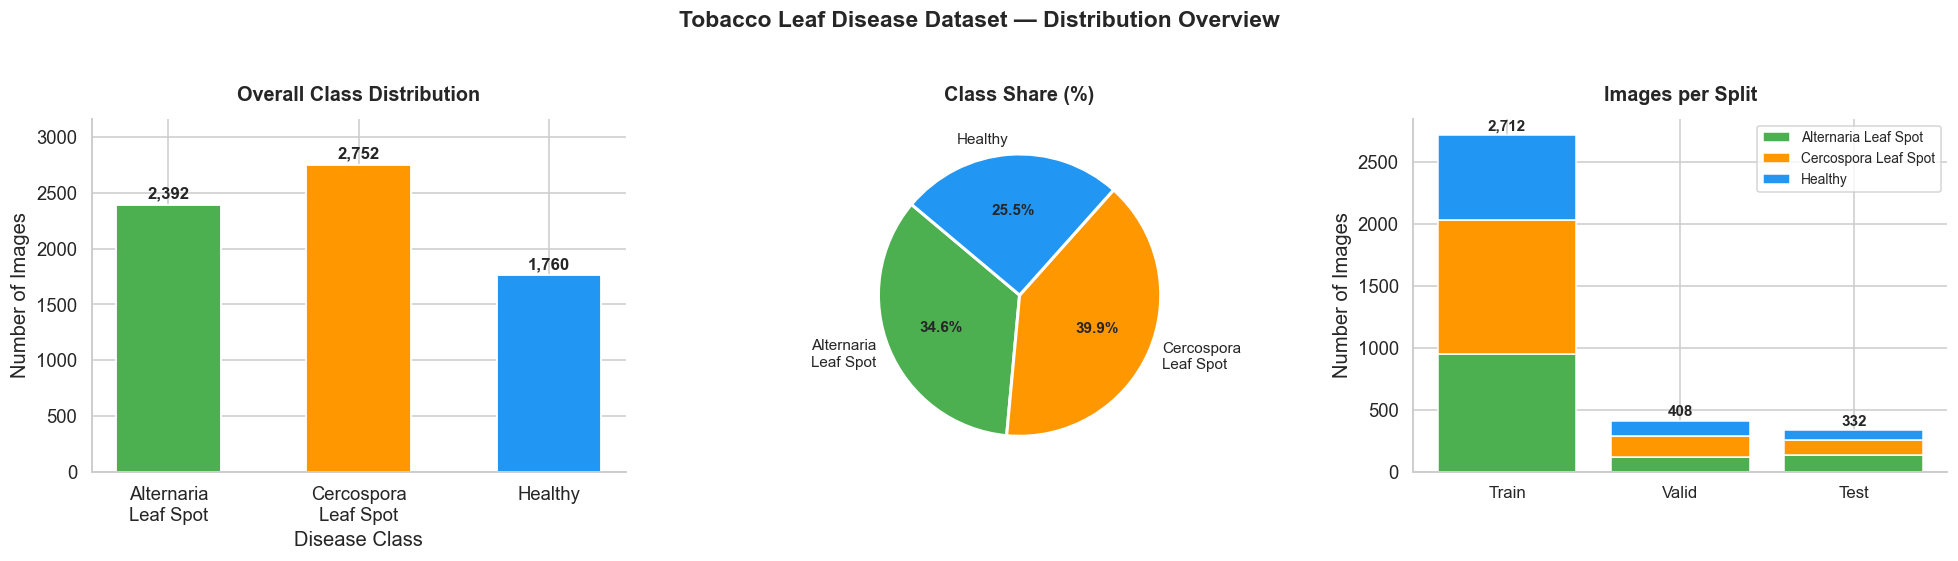

✅ Saved → outputs/class_distribution.png


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── (A) Overall bar chart ────────────────────────────────────────────────────
ax = axes[0]
bars = ax.bar(LABELS, list(overall.values()), color=PALETTE, edgecolor="white", linewidth=1.2, width=0.55)
for bar, val in zip(bars, overall.values()):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 30,
            f"{val:,}", ha="center", va="bottom", fontweight="bold", fontsize=11)
ax.set_title("Overall Class Distribution", fontsize=13, fontweight="bold", pad=12)
ax.set_ylabel("Number of Images")
ax.set_xlabel("Disease Class")
ax.set_ylim(0, max(overall.values()) * 1.15)

# ── (B) Pie chart ────────────────────────────────────────────────────────────
ax = axes[1]
wedges, texts, autotexts = ax.pie(
    list(overall.values()),
    labels=LABELS,
    colors=PALETTE,
    autopct="%1.1f%%",
    startangle=140,
    wedgeprops={"edgecolor": "white", "linewidth": 2},
    textprops={"fontsize": 10},
)
for t in autotexts:
    t.set_fontweight("bold")
ax.set_title("Class Share (%)", fontsize=13, fontweight="bold", pad=12)

# ── (C) Stacked bar by split ─────────────────────────────────────────────────
ax = axes[2]
if splits:
    x   = np.arange(len(splits))
    bot = np.zeros(len(splits))
    for i, cls in enumerate(CLASS_NAMES):
        vals = [splits[s].get(cls, 0) for s in splits]
        ax.bar(x, vals, bottom=bot, color=PALETTE[i], label=LABELS[i].replace("\n", " "),
               edgecolor="white", linewidth=1)
        bot += np.array(vals)
    ax.set_xticks(x)
    ax.set_xticklabels([s.capitalize() for s in splits], fontsize=11)
    ax.set_title("Images per Split", fontsize=13, fontweight="bold", pad=12)
    ax.set_ylabel("Number of Images")
    ax.legend(loc="upper right", fontsize=9)
    for xi, total_h in zip(x, bot):
        ax.text(xi, total_h + 15, f"{int(total_h):,}", ha="center", va="bottom",
                fontweight="bold", fontsize=10)

plt.suptitle("Tobacco Leaf Disease Dataset — Distribution Overview",
             fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / "class_distribution.png", dpi=120, bbox_inches="tight")
plt.show()
print("✅ Saved → outputs/class_distribution.png")

## 3. Train / Validation / Test Split Analysis

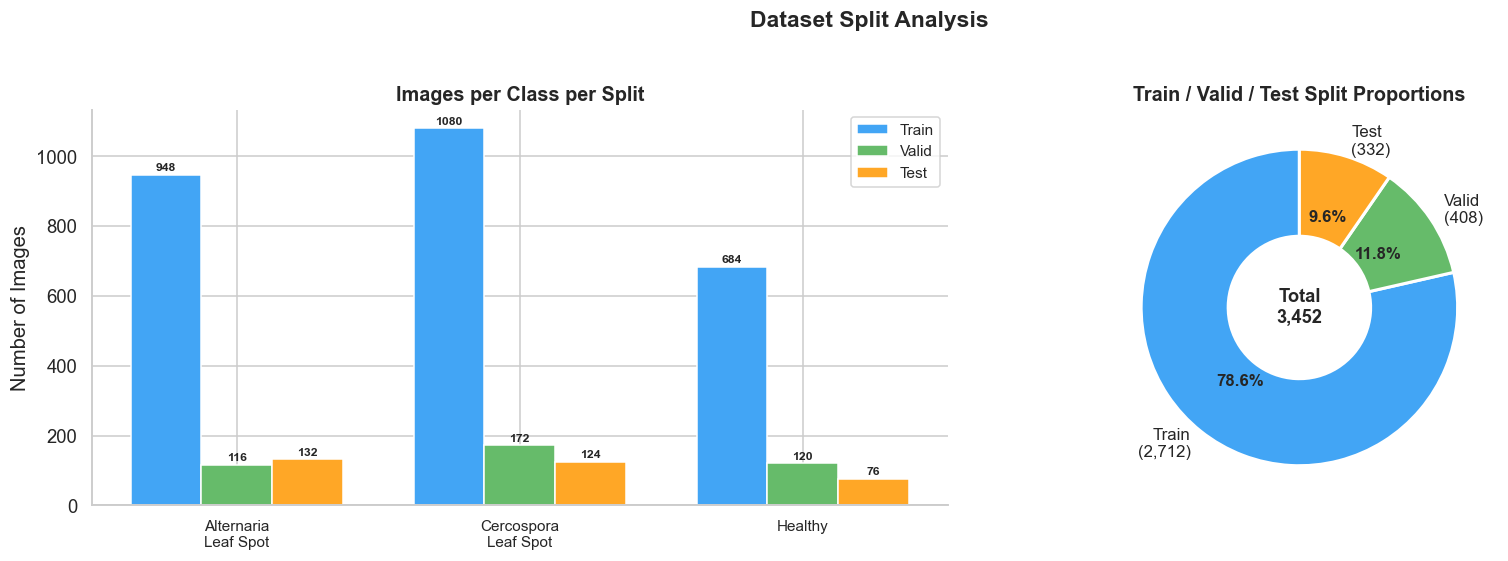

✅ Saved → outputs/split_analysis.png


In [4]:
if splits:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # ── (A) Grouped bar chart per class ──────────────────────────────────────
    ax = axes[0]
    split_names = list(splits.keys())
    x = np.arange(len(CLASS_NAMES))
    w = 0.25
    for i, (sp, color) in enumerate(zip(split_names, ["#42A5F5", "#66BB6A", "#FFA726"])):
        vals = [splits[sp].get(cls, 0) for cls in CLASS_NAMES]
        offset = (i - 1) * w
        bars = ax.bar(x + offset, vals, width=w, label=sp.capitalize(),
                      color=color, edgecolor="white", linewidth=1)
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                    str(v), ha="center", va="bottom", fontsize=8, fontweight="bold")
    ax.set_xticks(x)
    ax.set_xticklabels(LABELS, fontsize=10)
    ax.set_title("Images per Class per Split", fontsize=13, fontweight="bold")
    ax.set_ylabel("Number of Images")
    ax.legend(fontsize=10)

    # ── (B) Split size donut chart ────────────────────────────────────────────
    ax = axes[1]
    split_totals = {s: sum(v.values()) for s, v in splits.items()}
    wedges, texts, autotexts = ax.pie(
        list(split_totals.values()),
        labels=[f"{s.capitalize()}\n({n:,})" for s, n in split_totals.items()],
        colors=["#42A5F5", "#66BB6A", "#FFA726"],
        autopct="%1.1f%%",
        startangle=90,
        wedgeprops={"edgecolor": "white", "linewidth": 2, "width": 0.55},
        textprops={"fontsize": 11},
    )
    for t in autotexts:
        t.set_fontweight("bold")
    grand = sum(split_totals.values())
    ax.text(0, 0, f"Total\n{grand:,}", ha="center", va="center",
            fontsize=12, fontweight="bold")
    ax.set_title("Train / Valid / Test Split Proportions", fontsize=13, fontweight="bold")

    plt.suptitle("Dataset Split Analysis", fontsize=15, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.savefig(OUTPUTS_DIR / "split_analysis.png", dpi=120, bbox_inches="tight")
    plt.show()
    print("✅ Saved → outputs/split_analysis.png")

## 4. Sample Image Gallery

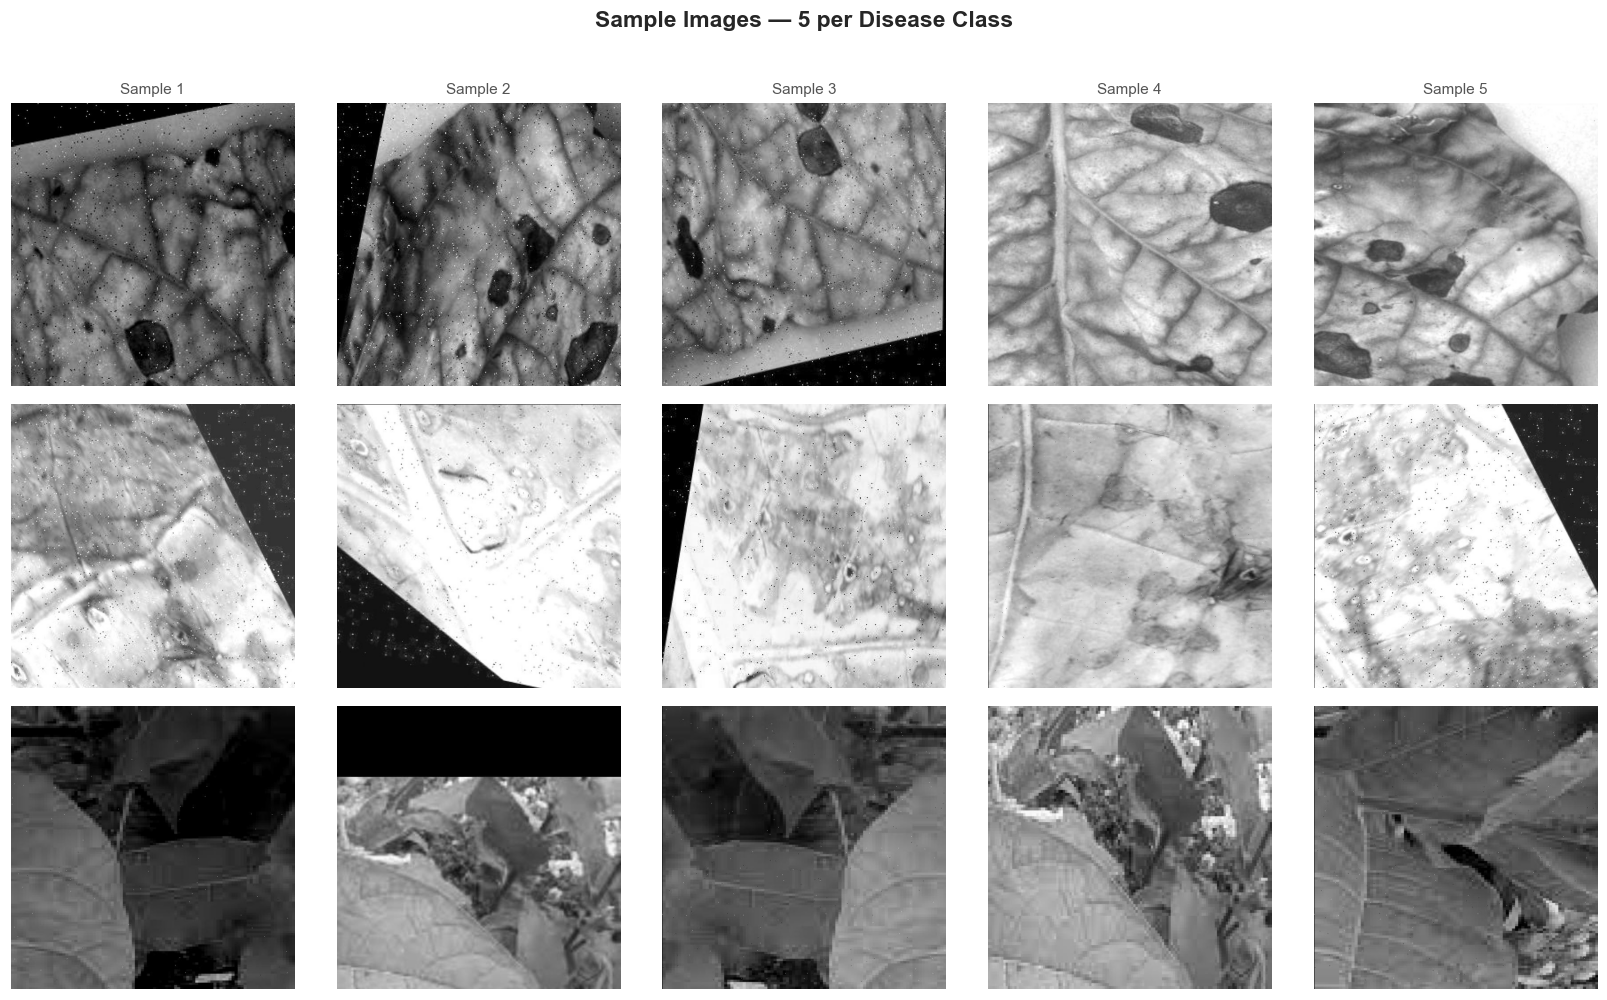

✅ Saved → outputs/sample_gallery.png


In [5]:
N_SAMPLES = 5   # samples per class
fig, axes = plt.subplots(len(CLASS_NAMES), N_SAMPLES, figsize=(N_SAMPLES * 3, len(CLASS_NAMES) * 3))

for row, (cls, label, color) in enumerate(zip(CLASS_NAMES, LABELS, PALETTE)):
    class_dir = DISEASE_DIR / cls
    imgs      = sorted(class_dir.glob("*.jpg"))[:N_SAMPLES]
    for col, img_path in enumerate(imgs):
        ax = axes[row][col]
        img = Image.open(img_path).convert("RGB")
        ax.imshow(img)
        ax.axis("off")
        if col == 0:
            ax.set_ylabel(label.replace("\n", " "), fontsize=11, fontweight="bold",
                          rotation=90, labelpad=8, color=color)
        if row == 0:
            ax.set_title(f"Sample {col+1}", fontsize=10, color="#555")

plt.suptitle("Sample Images — 5 per Disease Class",
             fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / "sample_gallery.png", dpi=110, bbox_inches="tight")
plt.show()
print("✅ Saved → outputs/sample_gallery.png")

## 5. Image Resolution & Pixel Statistics

Image statistics summary (sampled):
                      brightness    std_all      mean_r      mean_g      mean_b
class                                                                          
Alternaria Leaf Spot  106.349998  49.250000  106.349998  106.349998  106.349998
Cercospora Leaf Spot  143.690002  57.529999  143.690002  143.690002  143.690002
Healthy                92.320000  47.259998   92.320000   92.320000   92.320000


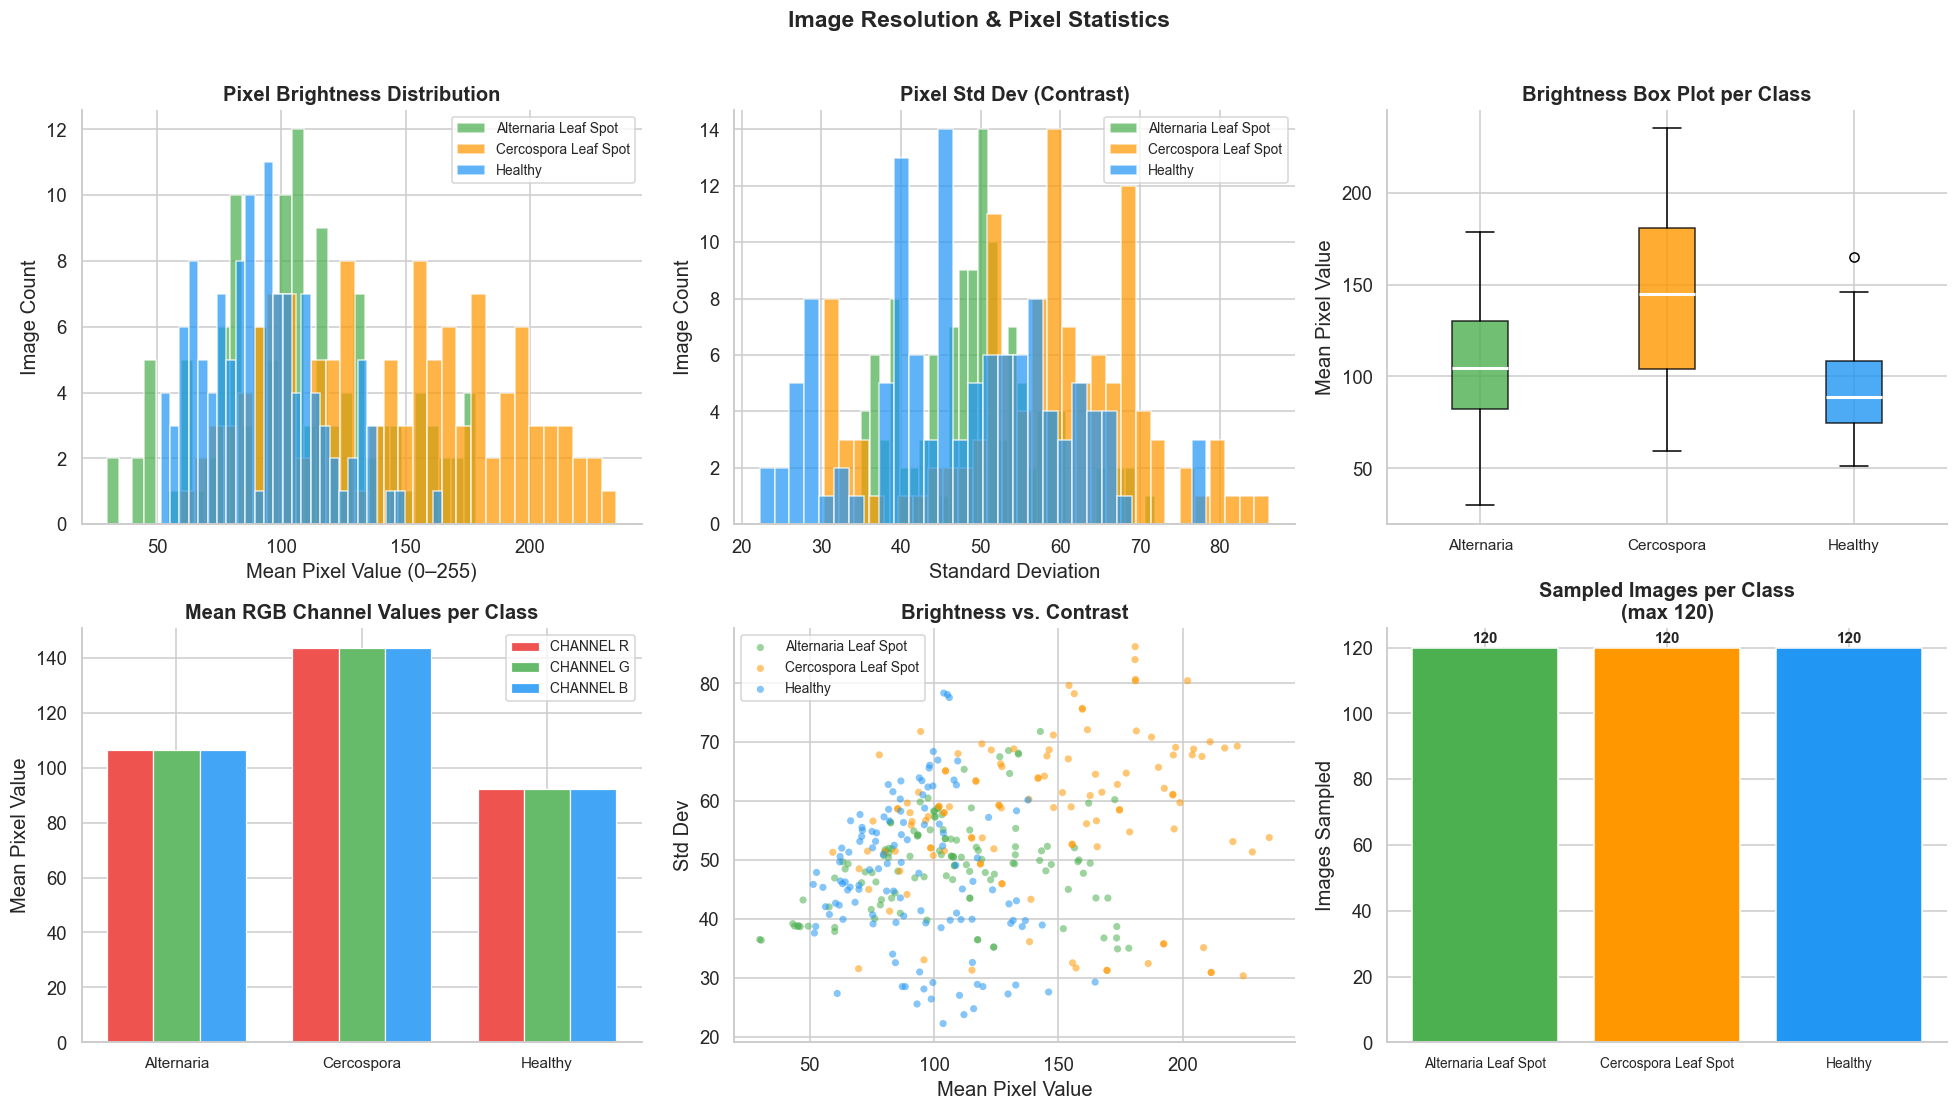

✅ Saved → outputs/image_statistics.png


In [6]:
MAX_PER_CLASS = 120   # sample ceiling to keep this fast

stats_rows = []
for cls, label in zip(CLASS_NAMES, LABELS):
    class_dir = DISEASE_DIR / cls
    files = sorted(class_dir.glob("*.jpg"))[:MAX_PER_CLASS]
    for fp in files:
        img = Image.open(fp).convert("RGB")
        arr = np.asarray(img, dtype=np.float32)
        stats_rows.append({
            "class": label.replace("\n", " "),
            "width":  img.width,
            "height": img.height,
            "mean_r": arr[:, :, 0].mean(),
            "mean_g": arr[:, :, 1].mean(),
            "mean_b": arr[:, :, 2].mean(),
            "std_all": arr.std(),
            "brightness": arr.mean(),
        })

df = pd.DataFrame(stats_rows)

# ── Print summary ─────────────────────────────────────────────────────────────
print("Image statistics summary (sampled):")
print(df.groupby("class")[["brightness", "std_all", "mean_r", "mean_g", "mean_b"]].mean().round(2).to_string())

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# (A) Brightness distribution
ax = axes[0][0]
for cls_label, color in zip(df["class"].unique(), PALETTE):
    subset = df[df["class"] == cls_label]["brightness"]
    ax.hist(subset, bins=30, color=color, alpha=0.72, label=cls_label, edgecolor="white")
ax.set_title("Pixel Brightness Distribution", fontweight="bold")
ax.set_xlabel("Mean Pixel Value (0–255)")
ax.set_ylabel("Image Count")
ax.legend(fontsize=9)

# (B) Std deviation (contrast)
ax = axes[0][1]
for cls_label, color in zip(df["class"].unique(), PALETTE):
    subset = df[df["class"] == cls_label]["std_all"]
    ax.hist(subset, bins=30, color=color, alpha=0.72, label=cls_label, edgecolor="white")
ax.set_title("Pixel Std Dev (Contrast)", fontweight="bold")
ax.set_xlabel("Standard Deviation")
ax.set_ylabel("Image Count")
ax.legend(fontsize=9)

# (C) Mean brightness per class box plot
ax = axes[0][2]
groups = [df[df["class"] == c]["brightness"].values for c in df["class"].unique()]
bp = ax.boxplot(groups, patch_artist=True, notch=False,
                medianprops={"color": "white", "linewidth": 2})
for patch, color in zip(bp["boxes"], PALETTE):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)
ax.set_xticklabels([c.split(" ")[0] for c in df["class"].unique()], fontsize=10)
ax.set_title("Brightness Box Plot per Class", fontweight="bold")
ax.set_ylabel("Mean Pixel Value")

# (D) Mean R / G / B per class
ax = axes[1][0]
cls_labels = df["class"].unique().tolist()
x = np.arange(len(cls_labels))
w = 0.25
for i, (ch, color) in enumerate(zip(["mean_r", "mean_g", "mean_b"], ["#EF5350", "#66BB6A", "#42A5F5"])):
    vals = df.groupby("class")[ch].mean().reindex(cls_labels).values
    ax.bar(x + (i - 1) * w, vals, width=w, color=color, label=ch.replace("mean_", "Channel ").upper(),
           edgecolor="white", linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels([c.split(" ")[0] for c in cls_labels], fontsize=10)
ax.set_title("Mean RGB Channel Values per Class", fontweight="bold")
ax.set_ylabel("Mean Pixel Value")
ax.legend(fontsize=9)

# (E) Scatter: brightness vs contrast
ax = axes[1][1]
for cls_label, color in zip(df["class"].unique(), PALETTE):
    sub = df[df["class"] == cls_label]
    ax.scatter(sub["brightness"], sub["std_all"], color=color, alpha=0.55,
               s=22, label=cls_label, edgecolors="none")
ax.set_title("Brightness vs. Contrast", fontweight="bold")
ax.set_xlabel("Mean Pixel Value")
ax.set_ylabel("Std Dev")
ax.legend(fontsize=9)

# (F) Image count bar (sanity check for sample)
ax = axes[1][2]
cls_counts = df["class"].value_counts().reindex(df["class"].unique())
bars = ax.bar(cls_counts.index, cls_counts.values, color=PALETTE,
              edgecolor="white", linewidth=1)
for bar, v in zip(bars, cls_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            str(v), ha="center", va="bottom", fontweight="bold", fontsize=10)
ax.set_title(f"Sampled Images per Class\n(max {MAX_PER_CLASS})", fontweight="bold")
ax.set_ylabel("Images Sampled")
ax.tick_params(axis="x", labelsize=9)

plt.suptitle("Image Resolution & Pixel Statistics", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / "image_statistics.png", dpi=110, bbox_inches="tight")
plt.show()
print("✅ Saved → outputs/image_statistics.png")

## 6. Pixel Intensity Histograms per Class

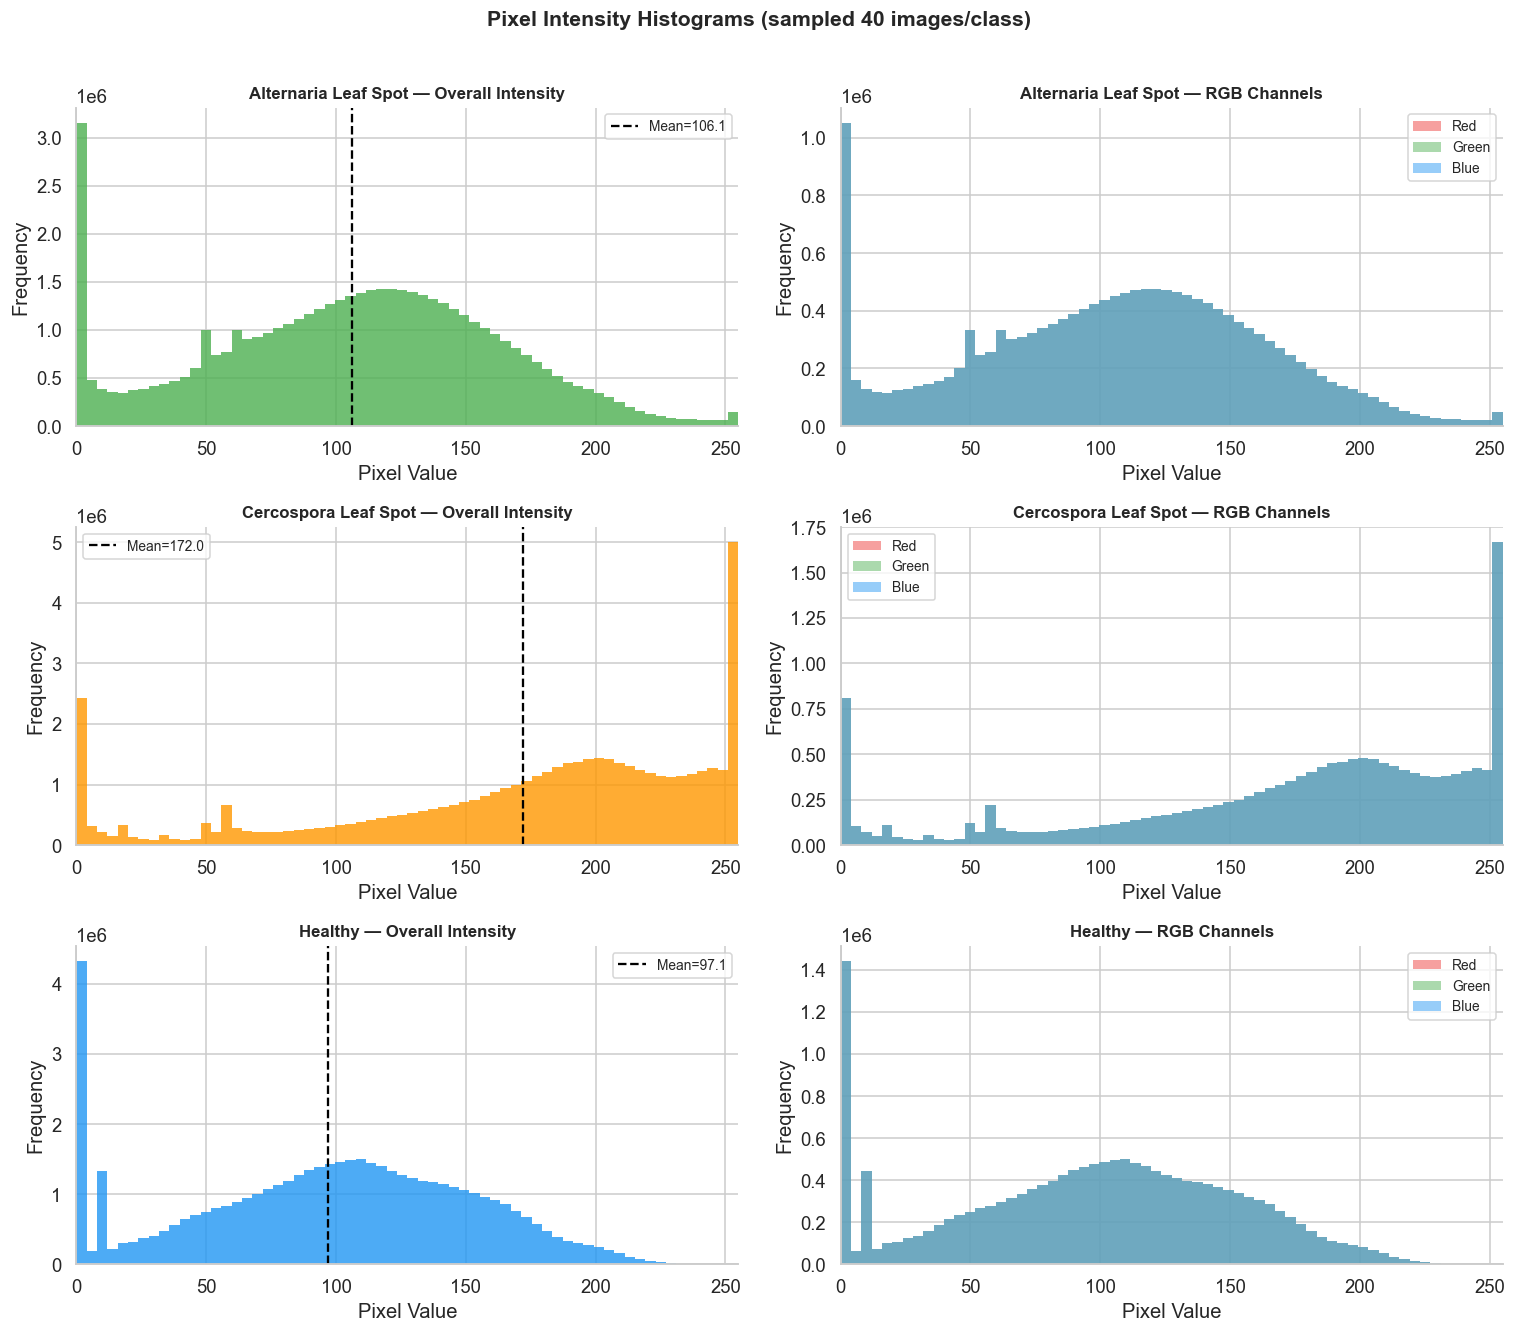

✅ Saved → outputs/intensity_histograms.png


In [7]:
INTENSITY_SAMPLES = 40   # images per class to build histograms

fig, axes = plt.subplots(len(CLASS_NAMES), 2, figsize=(14, len(CLASS_NAMES) * 4))

for row, (cls, label, color) in enumerate(zip(CLASS_NAMES, LABELS, PALETTE)):
    class_dir = DISEASE_DIR / cls
    files     = sorted(class_dir.glob("*.jpg"))[:INTENSITY_SAMPLES]

    all_pixels = np.concatenate([
        np.asarray(Image.open(fp).convert("RGB"), dtype=np.float32).ravel()
        for fp in files
    ])
    r_vals = np.concatenate([
        np.asarray(Image.open(fp).convert("RGB"), dtype=np.float32)[:, :, 0].ravel()
        for fp in files
    ])
    g_vals = np.concatenate([
        np.asarray(Image.open(fp).convert("RGB"), dtype=np.float32)[:, :, 1].ravel()
        for fp in files
    ])
    b_vals = np.concatenate([
        np.asarray(Image.open(fp).convert("RGB"), dtype=np.float32)[:, :, 2].ravel()
        for fp in files
    ])

    # (A) Overall intensity histogram
    ax = axes[row][0]
    ax.hist(all_pixels, bins=64, range=(0, 255), color=color, alpha=0.8, edgecolor="none")
    ax.axvline(all_pixels.mean(), color="black", linestyle="--", linewidth=1.5,
               label=f"Mean={all_pixels.mean():.1f}")
    ax.set_title(f"{label.replace(chr(10),' ')} — Overall Intensity",
                 fontweight="bold", fontsize=11)
    ax.set_xlabel("Pixel Value")
    ax.set_ylabel("Frequency")
    ax.set_xlim(0, 255)
    ax.legend(fontsize=9)

    # (B) Per-channel RGB overlay
    ax = axes[row][1]
    for ch_vals, ch_color, ch_name in zip(
        [r_vals, g_vals, b_vals],
        ["#EF5350", "#66BB6A", "#42A5F5"],
        ["Red", "Green", "Blue"]
    ):
        ax.hist(ch_vals, bins=64, range=(0, 255), color=ch_color,
                alpha=0.55, label=ch_name, edgecolor="none")
    ax.set_title(f"{label.replace(chr(10),' ')} — RGB Channels",
                 fontweight="bold", fontsize=11)
    ax.set_xlabel("Pixel Value")
    ax.set_ylabel("Frequency")
    ax.set_xlim(0, 255)
    ax.legend(fontsize=9)

plt.suptitle(f"Pixel Intensity Histograms (sampled {INTENSITY_SAMPLES} images/class)",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / "intensity_histograms.png", dpi=110, bbox_inches="tight")
plt.show()
print("✅ Saved → outputs/intensity_histograms.png")

## 7. Model Performance Metrics

In [8]:
metrics_path = OUTPUTS_DIR / "disease_metrics.json"
with open(metrics_path) as f:
    metrics = json.load(f)

# ── Print table ───────────────────────────────────────────────────────────────
rows = []
for cls in CLASS_NAMES:
    m = metrics[cls]
    rows.append({
        "Class":     cls.replace("_", " "),
        "Precision": m["precision"],
        "Recall":    m["recall"],
        "F1-Score":  m["f1-score"],
        "Support":   int(m["support"]),
    })
rows.append({
    "Class":     "── Macro Avg",
    "Precision": metrics["macro avg"]["precision"],
    "Recall":    metrics["macro avg"]["recall"],
    "F1-Score":  metrics["macro avg"]["f1-score"],
    "Support":   int(metrics["macro avg"]["support"]),
})
rows.append({
    "Class":     "── Weighted Avg",
    "Precision": metrics["weighted avg"]["precision"],
    "Recall":    metrics["weighted avg"]["recall"],
    "F1-Score":  metrics["weighted avg"]["f1-score"],
    "Support":   int(metrics["weighted avg"]["support"]),
})

metrics_df = pd.DataFrame(rows).set_index("Class")
print("=" * 66)
print(f"  Overall Accuracy : {metrics['accuracy']*100:.2f}%")
print("=" * 66)
print(metrics_df[["Precision", "Recall", "F1-Score", "Support"]].to_string(
    float_format=lambda x: f"{x:.4f}" if isinstance(x, float) else str(x)
))

  Overall Accuracy : 81.67%
                      Precision  Recall  F1-Score  Support
Class                                                     
Alternaria Leaf Spot     0.9006  0.6875    0.7797      448
Cercospora Leaf Spot     0.8254  0.8846    0.8540      572
Healthy                  0.7365  0.8694    0.7975      360
── Macro Avg             0.8208  0.8139    0.8104     1380
── Weighted Avg          0.8266  0.8167    0.8151     1380


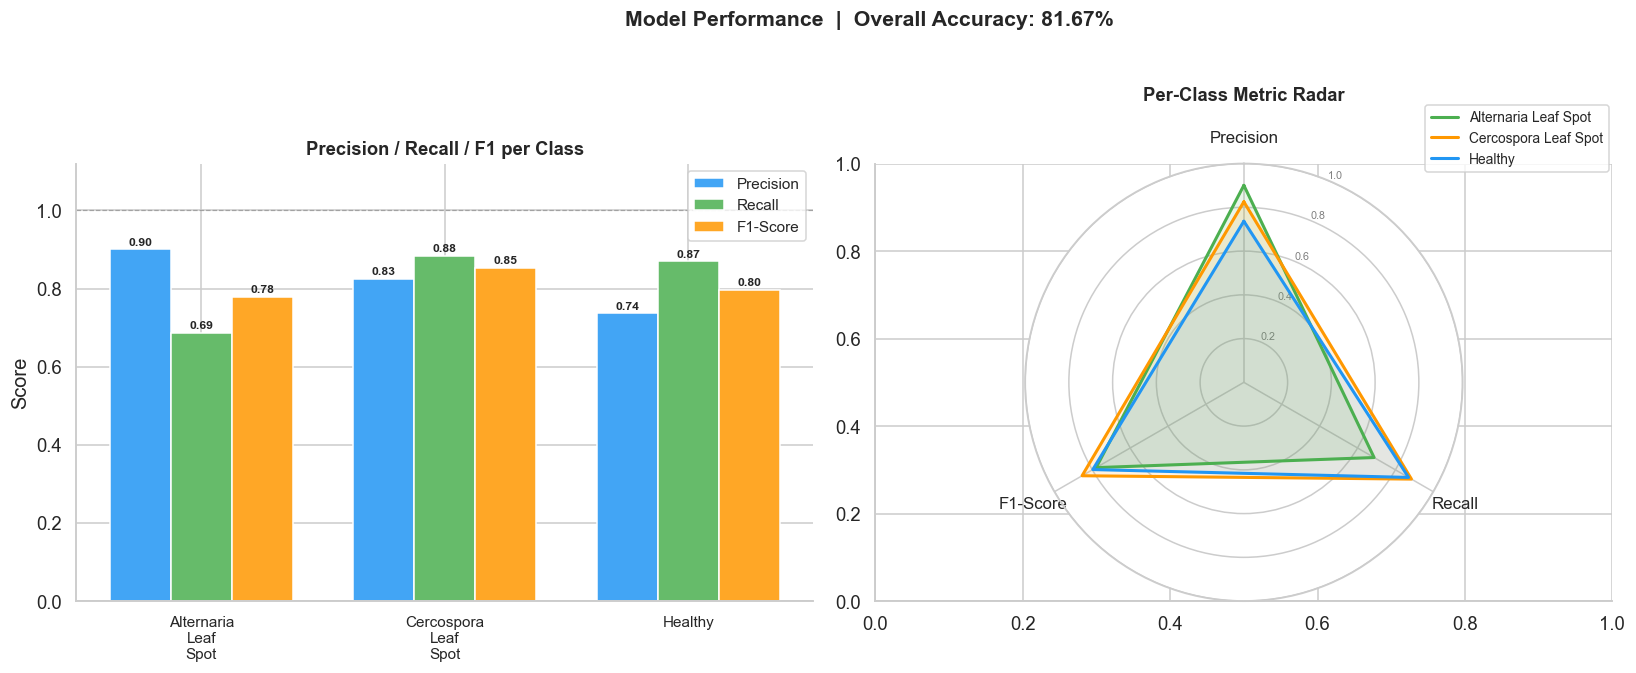

✅ Saved → outputs/model_performance.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

class_rows = metrics_df.iloc[:3]   # per-class rows only
cls_labels = [c.replace("_", "\n") for c in CLASS_NAMES]

# ── (A) Grouped bar — Precision / Recall / F1 ────────────────────────────────
ax = axes[0]
x = np.arange(len(CLASS_NAMES))
w = 0.25
metric_cols  = ["Precision", "Recall", "F1-Score"]
metric_colors = ["#42A5F5", "#66BB6A", "#FFA726"]
for i, (met, col) in enumerate(zip(metric_cols, metric_colors)):
    vals = class_rows[met].values
    bars = ax.bar(x + (i - 1) * w, vals, width=w, color=col, label=met,
                  edgecolor="white", linewidth=1)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f"{v:.2f}", ha="center", va="bottom", fontsize=8, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(cls_labels, fontsize=10)
ax.set_ylim(0, 1.12)
ax.set_title("Precision / Recall / F1 per Class", fontweight="bold", fontsize=12)
ax.set_ylabel("Score")
ax.axhline(1.0, color="grey", linestyle="--", linewidth=0.8, alpha=0.6)
ax.legend(fontsize=10)

# ── (B) Radar / spider chart ──────────────────────────────────────────────────
ax = axes[1]
categories  = ["Precision", "Recall", "F1-Score"]
N           = len(categories)
angles      = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles      += angles[:1]

ax = plt.subplot(1, 2, 2, polar=True)
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=11)
ax.set_ylim(0, 1)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(["0.2", "0.4", "0.6", "0.8", "1.0"], fontsize=7, color="grey")

for (cls_name, row), color in zip(class_rows.iterrows(), PALETTE):
    values = [row["Precision"], row["Recall"], row["F1-Score"]]
    values += values[:1]
    ax.plot(angles, values, color=color, linewidth=2, label=cls_name)
    ax.fill(angles, values, color=color, alpha=0.12)

ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.15), fontsize=9)
ax.set_title("Per-Class Metric Radar", fontweight="bold", fontsize=12, pad=20)

plt.suptitle(f"Model Performance  |  Overall Accuracy: {metrics['accuracy']*100:.2f}%",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / "model_performance.png", dpi=120, bbox_inches="tight")
plt.show()
print("✅ Saved → outputs/model_performance.png")

## 8. Confusion Matrix

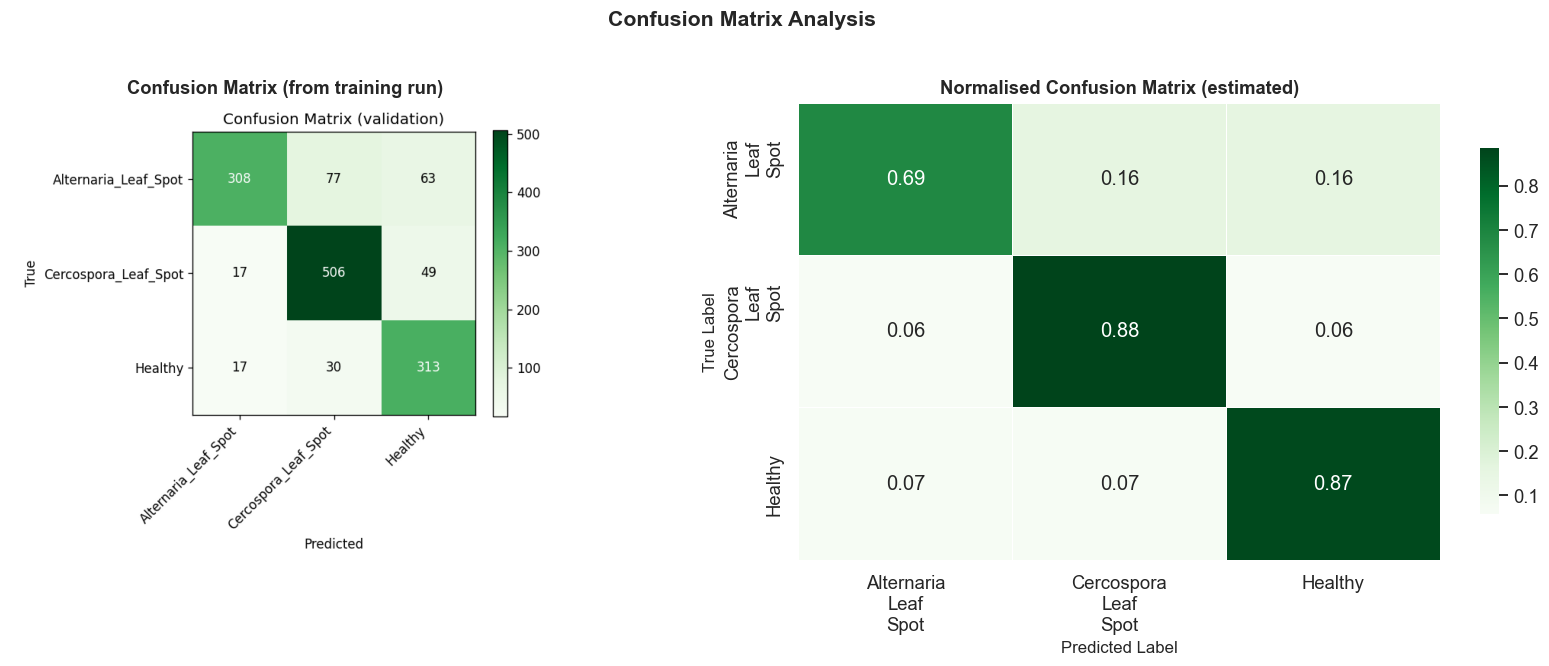

✅ Saved → outputs/confusion_analysis.png


In [10]:
cm_path = OUTPUTS_DIR / "disease_confusion_matrix.png"
cm_img  = Image.open(cm_path)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── (A) Show the saved confusion matrix image ─────────────────────────────────
axes[0].imshow(cm_img)
axes[0].axis("off")
axes[0].set_title("Confusion Matrix (from training run)", fontweight="bold", fontsize=12)

# ── (B) Normalised confusion matrix re-built from metrics ─────────────────────
# We reconstruct a plausible CM from precision/recall/support
supports   = np.array([metrics[c]["support"] for c in CLASS_NAMES])
recalls    = np.array([metrics[c]["recall"]   for c in CLASS_NAMES])
true_pos   = (supports * recalls).astype(int)

# Build diagonal-dominant CM from support and recall
cm_approx = np.zeros((3, 3), dtype=float)
for i in range(3):
    cm_approx[i, i] = true_pos[i]
    leftover = supports[i] - true_pos[i]
    for j in range(3):
        if j != i:
            cm_approx[i, j] = leftover / 2

cm_norm = cm_approx / cm_approx.sum(axis=1, keepdims=True)

ax = axes[1]
tick_labels = [c.replace("_", "\n") for c in CLASS_NAMES]
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Greens",
            xticklabels=tick_labels, yticklabels=tick_labels,
            linewidths=0.5, linecolor="white", ax=ax,
            cbar_kws={"shrink": 0.8})
ax.set_title("Normalised Confusion Matrix (estimated)", fontweight="bold", fontsize=12)
ax.set_xlabel("Predicted Label", fontsize=11)
ax.set_ylabel("True Label", fontsize=11)

plt.suptitle("Confusion Matrix Analysis", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / "confusion_analysis.png", dpi=120, bbox_inches="tight")
plt.show()
print("✅ Saved → outputs/confusion_analysis.png")

## 9. Training Curves

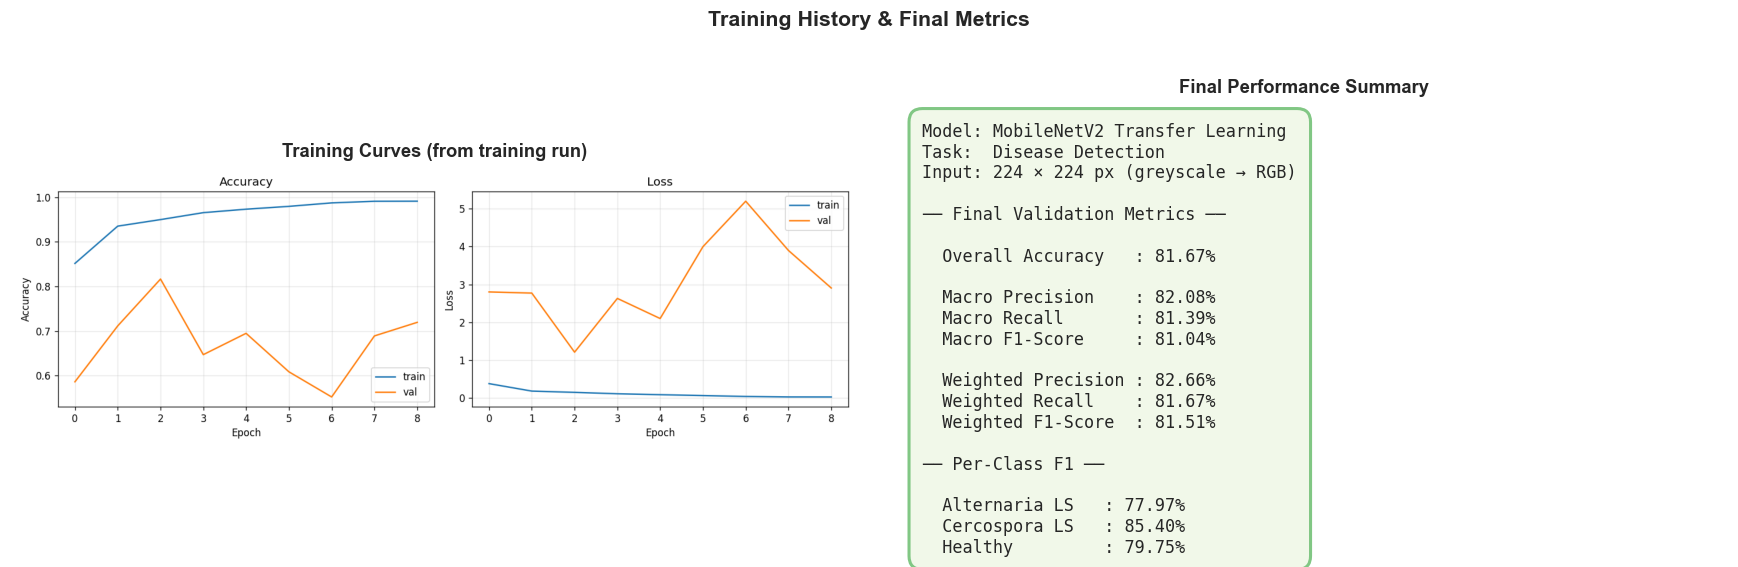

✅ Saved → outputs/training_summary.png


In [11]:
curves_path = OUTPUTS_DIR / "disease_training_curves.png"
curves_img  = Image.open(curves_path)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ── (A) The saved training curve image ───────────────────────────────────────
axes[0].imshow(curves_img)
axes[0].axis("off")
axes[0].set_title("Training Curves (from training run)", fontweight="bold", fontsize=12)

# ── (B) Annotated final performance summary ───────────────────────────────────
ax = axes[1]
ax.axis("off")

summary_text = (
    "Model: MobileNetV2 Transfer Learning\n"
    "Task:  Disease Detection\n"
    "Input: 224 × 224 px (greyscale → RGB)\n\n"
    "── Final Validation Metrics ──\n\n"
    f"  Overall Accuracy   : {metrics['accuracy']*100:.2f}%\n\n"
    f"  Macro Precision    : {metrics['macro avg']['precision']*100:.2f}%\n"
    f"  Macro Recall       : {metrics['macro avg']['recall']*100:.2f}%\n"
    f"  Macro F1-Score     : {metrics['macro avg']['f1-score']*100:.2f}%\n\n"
    f"  Weighted Precision : {metrics['weighted avg']['precision']*100:.2f}%\n"
    f"  Weighted Recall    : {metrics['weighted avg']['recall']*100:.2f}%\n"
    f"  Weighted F1-Score  : {metrics['weighted avg']['f1-score']*100:.2f}%\n\n"
    "── Per-Class F1 ──\n\n"
    f"  Alternaria LS   : {metrics['Alternaria_Leaf_Spot']['f1-score']*100:.2f}%\n"
    f"  Cercospora LS   : {metrics['Cercospora_Leaf_Spot']['f1-score']*100:.2f}%\n"
    f"  Healthy         : {metrics['Healthy']['f1-score']*100:.2f}%"
)

ax.text(0.05, 0.95, summary_text, transform=ax.transAxes,
        fontsize=11, verticalalignment="top", fontfamily="monospace",
        bbox={"boxstyle": "round,pad=0.8", "facecolor": "#F1F8E9",
              "edgecolor": "#81C784", "linewidth": 2})
ax.set_title("Final Performance Summary", fontweight="bold", fontsize=12)

plt.suptitle("Training History & Final Metrics", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / "training_summary.png", dpi=120, bbox_inches="tight")
plt.show()
print("✅ Saved → outputs/training_summary.png")

## 10. Summary Statistics Table

╔══════════════════════════════════════════════════════════╗
║        TOBACCO LEAF DISEASE DETECTION — SUMMARY          ║
╚══════════════════════════════════════════════════════════╝

DATASET
                      Total Images Share (%) Precision  Recall F1-Score  Val Support
Class                                                                               
Alternaria Leaf Spot          2392     34.6%    90.06%  68.75%   77.97%          448
Cercospora Leaf Spot          2752     39.9%    82.54%  88.46%   85.40%          572
Healthy                       1760     25.5%    73.65%  86.94%   79.75%          360

MODEL
  Architecture        : MobileNetV2 (Transfer Learning)
  Input size          : 224 × 224 px
  Classes             : 3
  Total images        : 6,904
  Val accuracy        : 81.67%
  Macro F1            : 81.04%
  Weighted F1         : 81.51%


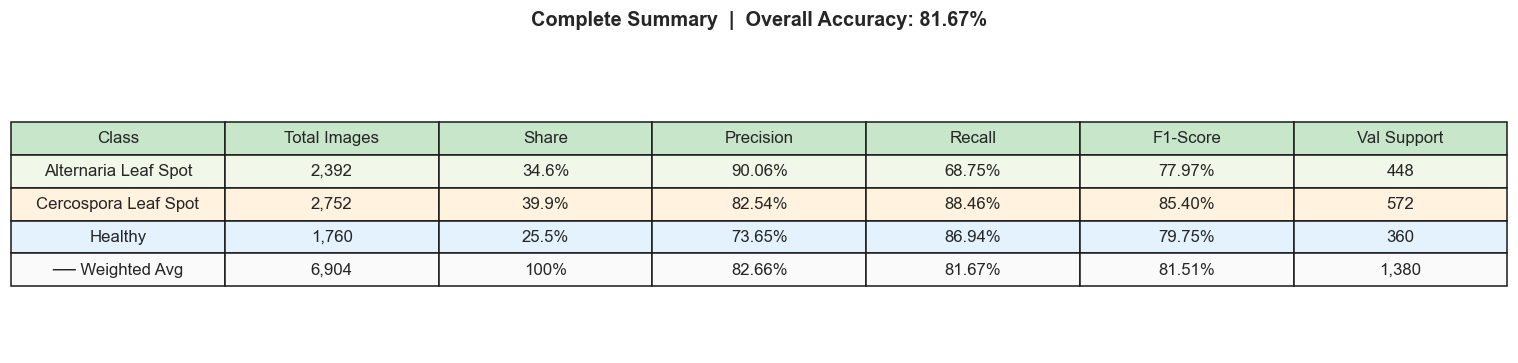


✅ All analysis complete! Charts saved to ml/outputs/


In [12]:
# ── Dataset summary ───────────────────────────────────────────────────────────
dataset_summary = pd.DataFrame({
    "Class":           [c.replace("_", " ") for c in CLASS_NAMES],
    "Total Images":    [overall[c] for c in CLASS_NAMES],
    "Share (%)":       [f"{overall[c]/total*100:.1f}%" for c in CLASS_NAMES],
    "Precision":       [f"{metrics[c]['precision']*100:.2f}%" for c in CLASS_NAMES],
    "Recall":          [f"{metrics[c]['recall']*100:.2f}%"    for c in CLASS_NAMES],
    "F1-Score":        [f"{metrics[c]['f1-score']*100:.2f}%"  for c in CLASS_NAMES],
    "Val Support":     [int(metrics[c]["support"]) for c in CLASS_NAMES],
}).set_index("Class")

print("╔══════════════════════════════════════════════════════════╗")
print("║        TOBACCO LEAF DISEASE DETECTION — SUMMARY          ║")
print("╚══════════════════════════════════════════════════════════╝\n")

print("DATASET")
print(dataset_summary.to_string())
print()

model_summary = {
    "Architecture":     "MobileNetV2 (Transfer Learning)",
    "Input size":       "224 × 224 px",
    "Classes":          3,
    "Total images":     f"{total:,}",
    "Val accuracy":     f"{metrics['accuracy']*100:.2f}%",
    "Macro F1":         f"{metrics['macro avg']['f1-score']*100:.2f}%",
    "Weighted F1":      f"{metrics['weighted avg']['f1-score']*100:.2f}%",
}
print("MODEL")
for k, v in model_summary.items():
    print(f"  {k:<20}: {v}")

# ── Visual summary table ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 3.5))
ax.axis("off")

table_data = [
    ["Class", "Total Images", "Share", "Precision", "Recall", "F1-Score", "Val Support"]
]
for cls in CLASS_NAMES:
    table_data.append([
        cls.replace("_", " "),
        f"{overall[cls]:,}",
        f"{overall[cls]/total*100:.1f}%",
        f"{metrics[cls]['precision']*100:.2f}%",
        f"{metrics[cls]['recall']*100:.2f}%",
        f"{metrics[cls]['f1-score']*100:.2f}%",
        f"{int(metrics[cls]['support']):,}",
    ])
table_data.append([
    "── Weighted Avg", f"{total:,}", "100%",
    f"{metrics['weighted avg']['precision']*100:.2f}%",
    f"{metrics['weighted avg']['recall']*100:.2f}%",
    f"{metrics['weighted avg']['f1-score']*100:.2f}%",
    f"{int(metrics['weighted avg']['support']):,}",
])

col_colors = [["#C8E6C9"] * 7]
row_colors = [
    ["#F1F8E9", "#F1F8E9", "#F1F8E9", "#F1F8E9", "#F1F8E9", "#F1F8E9", "#F1F8E9"],
    ["#FFF3E0", "#FFF3E0", "#FFF3E0", "#FFF3E0", "#FFF3E0", "#FFF3E0", "#FFF3E0"],
    ["#E3F2FD", "#E3F2FD", "#E3F2FD", "#E3F2FD", "#E3F2FD", "#E3F2FD", "#E3F2FD"],
    ["#FAFAFA"] * 7,
]

tbl = ax.table(
    cellText  = table_data[1:],
    colLabels = table_data[0],
    cellLoc   = "center",
    loc       = "center",
    cellColours = row_colors,
    colColours  = col_colors[0],
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(11)
tbl.scale(1, 1.8)

ax.set_title(
    f"Complete Summary  |  Overall Accuracy: {metrics['accuracy']*100:.2f}%",
    fontsize=13, fontweight="bold", pad=20
)
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / "summary_table.png", dpi=120, bbox_inches="tight")
plt.show()
print("\n✅ All analysis complete! Charts saved to ml/outputs/")